# Losing energy, getting hotter: an isolated gravitational cluster

Can a system become hotter when we remove energy? A bound gravitating cluster can: it contracts, releasing potential energy into motion.

We compare the **same cluster before and after gentle energy removal**, with free evolution between measurements. Each point represents a star-like point mass, not a gas atom. This is a small dynamical demonstration of negative heat capacity, not a model of the internal temperature of stars.

## 1. Prepare an isolated cluster

`Plummer` makes a spherical distribution of positions **and velocities** that is approximately stationary under gravity. We still allow it to settle before measuring. The initial scale radius is 1 and each particle has mass 1. We use `G = 1/N` to keep the dynamical time convenient at this particle count. All numbers use our fixed reduced reference units, with kB = 1; there is no LJ interaction in this example.

Every pair interacts, with **no cutoff, periodic copies or walls**. `softening=0` selects exact Newtonian gravity. Here a smoothing length of 0.05 prevents very close encounters from requiring extremely small timesteps:

- Pair energy: `U(r) = -G*m_i*m_j / sqrt(r² + softening²)`.
- Attractive force magnitude: `F(r) = G*m_i*m_j*r / (r² + softening²)^(3/2)`.

At separations much larger than the smoothing length this approaches the inverse-square force. The approximation is checked below. The Plummer scale radius describes the whole cluster; the smoothing length describes individual close encounters.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fys2160_md import Plummer, MDSimulation, Run

N = 256
G = 1 / N
softening = 0.05

cluster = Plummer(
    N=N, scale_radius=1.0, mass=1.0,
    G=G, softening=softening, seed=87287,
)
sim = MDSimulation(
    cluster,
    pair_potential="gravity", G=G, softening=softening,
    ensemble="nve", timestep=0.005, cutoff=None,
)

sim.run(
    steps=4000, heat_rate=0,
    thermo_every=20, trajectory_every=100,
    storage_name="gravity-relax",
);

## 2. Measure, remove energy, and measure again

`ensemble="nve"` selects free Newtonian dynamics here: there is no thermostat or pressure control. Since the cluster is unconfined, there is no prescribed physical volume. Its extent can change.

The first measurement lasts 20 time units. We then use `heat_rate=-0.4` for another 20, removing a total energy of 8. The solver removes kinetic energy by small uniform velocity rescalings at each step. This is an imposed energy sink, not a detailed model of stellar radiation. **Energy is not conserved while the sink is active.**

We explicitly set `heat_rate=0` afterwards, wait 20 time units, and take a longer final measurement. Both measurements have the sink switched off. No velocities or temperatures are reset between runs.

In [2]:
before = sim.run(
    steps=4000, heat_rate=0,
    thermo_every=20, trajectory_every=100,
    storage_name="gravity-before",
)
removal = sim.run(
    steps=4000, heat_rate=-0.4,
    thermo_every=20, trajectory_every=100,
    storage_name="gravity-remove",
)
sim.run(
    steps=4000, heat_rate=0,
    thermo_every=20, trajectory_every=100,
    storage_name="gravity-settle",
)
after = sim.run(
    steps=8000, heat_rate=0,
    thermo_every=20, trajectory_every=100,
    storage_name="gravity-after",
)

## 3. Read the measurements from disk

The remaining cells work with saved output. They can be rerun without rerunning the dynamics. Reusing a storage name in the cells above overwrites that particular run.

The reported kinetic temperature is `T = 2*K/(3*N - 3)`, with the three center-of-mass velocity degrees of freedom removed. In a stellar cluster this measures random particle motion; it does not imply a spatially uniform gas temperature.

In [3]:
names = ["relax", "before", "remove", "settle", "after"]
data = {
    name: Run.load(f"runs/gravity-{name}").thermo
    for name in names
}
before_data = data["before"]
after_data = data["after"]

print("Measurement      mean E    mean T    half-mass radius    2K/(-W)")
for name in ["before", "after"]:
    d = data[name]
    ratio = 2 * d.kinetic_energy.mean() / (-d.virial.mean())
    print(f"{name:12s} {d.total_energy.mean():9.3f} "
          f"{d.temperature.mean():9.4f} {d.half_mass_radius.mean():15.3f} "
          f"{ratio:12.3f}")

change_E = after_data.total_energy.mean() - before_data.total_energy.mean()
change_T = after_data.temperature.mean() - before_data.temperature.mean()
print(f"Energy change: {change_E:.3f}")
print(f"Temperature change: {change_T:+.4f}")
print(f"Finite-difference response ΔE/ΔT: {change_E/change_T:.0f} (kB = 1)")

Measurement      mean E    mean T    half-mass radius    2K/(-W)
before         -36.744    0.0971           1.343        1.013
after          -44.744    0.1144           1.061        0.999
Energy change: -8.000
Temperature change: +0.0173
Finite-difference response ΔE/ΔT: -462 (kB = 1)


The final cluster has **less total energy, greater kinetic temperature, and a smaller half-mass radius**. The radius encloses half the mass around the center of mass. Negative ΔE/ΔT is the effect we wanted to illustrate. It is a finite difference between two approximately steady states, not a precision measurement of an equilibrium heat-capacity curve.

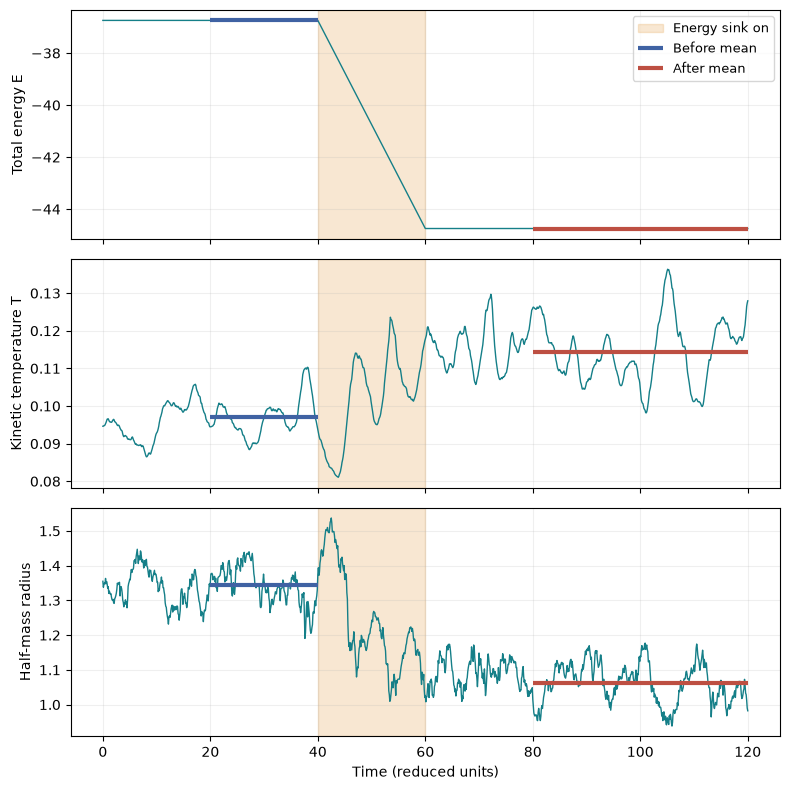

In [4]:
all_data = pd.concat([data[name] for name in names]).drop_duplicates("step")
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
for ax, quantity, label in zip(
    axes,
    ["total_energy", "temperature", "half_mass_radius"],
    ["Total energy E", "Kinetic temperature T", "Half-mass radius"],
):
    ax.plot(all_data.time, all_data[quantity], color="#157f88", linewidth=1)
    ax.axvspan(40, 60, color="#e4a34e", alpha=0.25, label="Energy sink on")
    for name, color in [("before", "#3f62a3"), ("after", "#bd4f42")]:
        d = data[name]
        ax.hlines(d[quantity].mean(), d.time.iloc[0], d.time.iloc[-1],
                  color=color, linewidth=3, label=f"{name.capitalize()} mean")
    ax.set_ylabel(label)
    ax.grid(alpha=0.2)
axes[0].legend(loc="best", fontsize=9)
axes[-1].set_xlabel("Time (reduced units)")
fig.tight_layout()
plt.show()

## 4. Why does this happen?

For an isolated bound system that has settled, the time-averaged virial relation is `2 mean(K) + mean(W) ≈ 0`, where W is the force virial, the sum of pair separation dotted with pair force.

For exact Newtonian gravity, **W = U**, so `E = K + U ≈ -K`. Combining this with `K = (3N - 3)T/2` gives `dE/dT ≈ -(3N - 3)/2` along a sequence of such states.

Removing energy initially reduces the motion supporting the cluster. It contracts. Its gravitational potential energy decreases, and part of that decrease becomes kinetic energy. After settling, the cluster can therefore be **hotter despite having lost energy**. A short-time dip or oscillation in temperature during the removal is compatible with this argument: the relation concerns settled averages.

Softened gravity has W slightly different from U. We use the actual force virial when checking relaxation, and show the unsoftened relation as an approximate reference rather than forcing the data onto it.

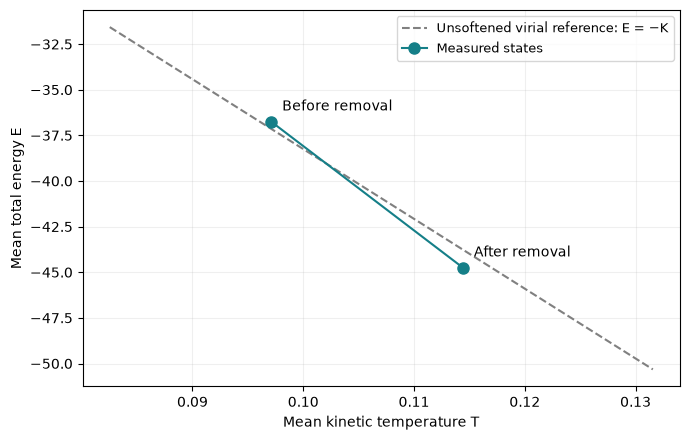

In [5]:
energies = np.array([before_data.total_energy.mean(), after_data.total_energy.mean()])
temperatures = np.array([before_data.temperature.mean(), after_data.temperature.mean()])
T_line = np.linspace(0.85 * temperatures.min(), 1.15 * temperatures.max(), 100)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(T_line, -(3*N - 3)/2 * T_line, "--", color="0.5", label="Unsoftened virial reference: E = −K")
ax.plot(temperatures, energies, "o-", color="#157f88", markersize=8, label="Measured states")
for T, E, label in zip(temperatures, energies, ["Before removal", "After removal"]):
    ax.annotate(label, (T, E), xytext=(8, 8), textcoords="offset points")
ax.set(xlabel="Mean kinetic temperature T", ylabel="Mean total energy E")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

## 5. Check the interpretation

Energy should change by exactly the imposed energy removal, apart from integration error. Thus `E - heat_added` should remain almost constant throughout the experiment. The virial ratio should fluctuate around 1 in the measurement windows.

These checks cannot establish full thermodynamic equilibrium. An unconfined finite cluster can slowly evolve and eject particles; gravitational systems do not have the same ordinary equilibrium limit as a short-range periodic gas. All particles remain in our energy accounting even if they travel far away. We interpret this run as a demonstration over approximately steady dynamical states.

Largest energy-balance error: 0.000341
Compared with energy removed: 8.000
before: mean W / mean U = 0.9929
after: mean W / mean U = 0.9896


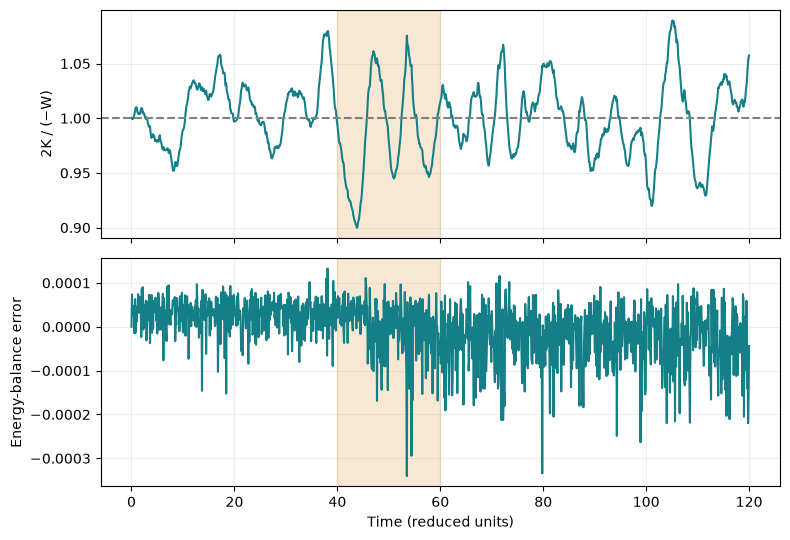

In [6]:
balance = all_data.total_energy - all_data.heat_added
balance_error = balance - balance.iloc[0]
print(f"Largest energy-balance error: {np.abs(balance_error).max():.6f}")
print(f"Compared with energy removed: {abs(change_E):.3f}")
for name in ["before", "after"]:
    d = data[name]
    print(f"{name}: mean W / mean U = {d.virial.mean()/d.potential_energy.mean():.4f}")

fig, axes = plt.subplots(2, 1, figsize=(8, 5.5), sharex=True)
axes[0].plot(all_data.time, all_data.virial_ratio, color="#157f88")
axes[0].axhline(1, color="0.5", linestyle="--")
axes[0].set_ylabel("2K / (−W)")
axes[1].plot(all_data.time, balance_error, color="#157f88")
axes[1].set_ylabel("Energy-balance error")
axes[1].set_xlabel("Time (reduced units)")
for ax in axes:
    ax.axvspan(40, 60, color="#e4a34e", alpha=0.25)
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

## 6. Replay the energy-removal stage

The display radius of 0.035 is only a marker size; it has no effect on gravity. There is no containing box. The camera shows the central cluster; distant particles can leave the view and still interact with all the others. Rotate, zoom or pan to inspect the motion.

This player uses recorded coordinates and works on the documentation page without a Python kernel. For live viewing in Jupyter, add `show=True, max_fps=20, frame_every=100` to a run.

In [7]:
Run.load("runs/gravity-remove").view(
    max_frames=101, projection="perspective", zoom=2,
    particle_radius=0.035,
)

## What to try next

- Change the energy-removal rate and compare **settled averages**, not single frames.
- Halve the timestep and check the energy balance again.
- Reduce the softening length together with the timestep. Exact gravity (`softening=0`) can produce tightly bound pairs that need much smaller timesteps.
- Run a comparison with `heat_rate=0` throughout to measure the cluster's natural evolution.

Changing the force to a truncated or periodic one changes the physical problem. Ewald summation is a way of including periodic copies; it is not needed for this isolated all-pairs calculation. Negative heat capacity is not guaranteed by an inverse-square force alone.

Further reading: [Lynden-Bell, *Negative Specific Heat in Astronomy, Physics and Chemistry*](https://arxiv.org/abs/cond-mat/9812172); [Maggs, *The virial theorem with periodic boundary conditions*](https://arxiv.org/abs/2302.12807).